# Import libraries

In [1]:
!pip uninstall -y mlxtend
!pip install mlxtend==0.23.4 scikit-learn==1.6.1
!pip install -q torchmetrics -U mlxtend

Found existing installation: mlxtend 0.23.4
Uninstalling mlxtend-0.23.4:
  Successfully uninstalled mlxtend-0.23.4
  Using cached mlxtend-0.23.4-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.23.4-py3-none-any.whl (1.4 MB)


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from timeit import default_timer as timer
from helper_functions import accuracy_fn
import random
import torchmetrics, mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Data loading

In [3]:
train_data = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

test_data = datasets.MNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

In [4]:
print("Кількість елементів у навчальному наборі:", len(train_data.data))
print("Кількість елементів у тестовому наборі:", len(test_data.data))

Кількість елементів у навчальному наборі: 60000
Кількість елементів у тестовому наборі: 10000


In [5]:
image, label = train_data[0]
print("Розмірність картинки:", image.shape)

Розмірність картинки: torch.Size([1, 28, 28])


In [6]:
class_names = train_data.classes
print("Класи набору даних:")
class_names

Класи набору даних:


['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

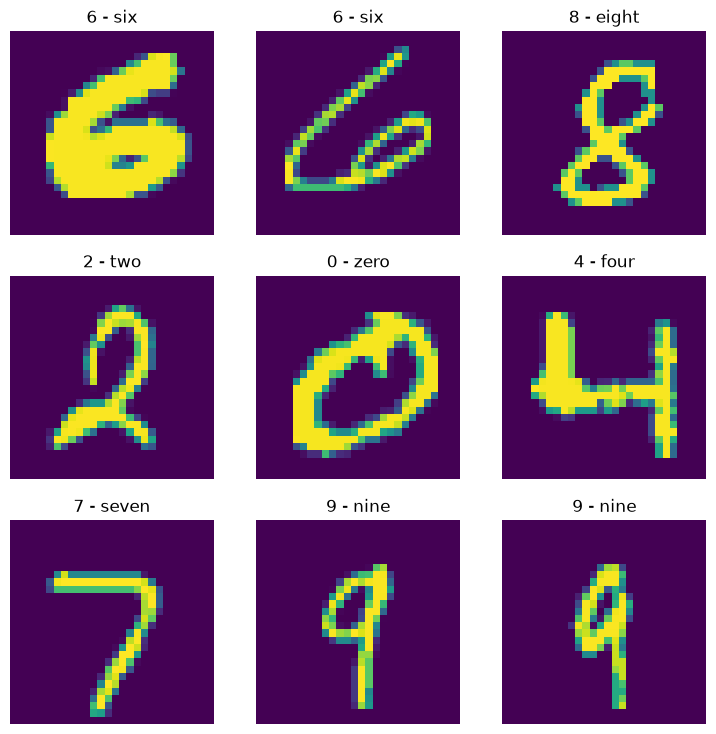

In [7]:
torch.manual_seed(42)
fig = plt.figure(figsize = (9, 9))
rows, cols = 3, 3
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size = [1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze())
  plt.title(class_names[label])
  plt.axis(False);

# Converting MNIST training and test datasets into data loaders

In [8]:
batch_size = 32

train_dataloader = DataLoader(train_data, batch_size, shuffle = True)
test_dataloader = DataLoader(test_data, batch_size, shuffle = False)

train_feature_batch, train_labels_batch = next(iter(train_dataloader))
test_feature_batch, test_labels_batch = next(iter(test_dataloader))

print("Навчальний DataLoader:", train_dataloader)
print(f"Довжина навчального DataLoader: {len(train_dataloader)} партій по {batch_size}")
print(f"Форма ознак навчального DataLoader {train_feature_batch.shape} та мітки {train_labels_batch.shape}")

print("Тестовий DataLoader:", test_dataloader)
print(f"Довжина тестового DataLoader: {len(test_dataloader)} партій по {batch_size}")
print(f"Форма ознак тестового DataLoader {test_feature_batch.shape} та мітки {test_labels_batch.shape}")

Навчальний DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x78a97f215ee0>
Довжина навчального DataLoader: 1875 партій по 32
Форма ознак навчального DataLoader torch.Size([32, 1, 28, 28]) та мітки torch.Size([32])
Тестовий DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x78a97f23e930>
Довжина тестового DataLoader: 313 партій по 32
Форма ознак тестового DataLoader torch.Size([32, 1, 28, 28]) та мітки torch.Size([32])


# CCN model
The model from [CNN Explainer](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG, is capable of training on the MNIST dataset.

In [9]:
class MNISTModelV2(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
torch.manual_seed(42)
model_2 = MNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

MNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

In [13]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:

            X, y = X.to(device), y.to(device)

            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

def print_train_time(start: float, end: float, device: torch.device = None):

    total_time = end - start
    print(f"Час навчання на {device}: {total_time:.3f} секунд")
    return total_time


def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):

    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}

In [14]:
# Навчання тієї ж архітектури на CPU для порівняння часу
torch.manual_seed(42)
model_2_cpu = MNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to("cpu")

loss_fn_cpu = nn.CrossEntropyLoss()
optimizer_cpu = torch.optim.SGD(params=model_2_cpu.parameters(), lr=0.1)

torch.manual_seed(42)

train_time_start_cpu = timer()

epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2_cpu,
        loss_fn=loss_fn_cpu,
        optimizer=optimizer_cpu,
        accuracy_fn=accuracy_fn,
        device="cpu"
    )
    test_step(data_loader=test_dataloader,
        model=model_2_cpu,
        loss_fn=loss_fn_cpu,
        accuracy_fn=accuracy_fn,
        device="cpu"
    )

train_time_end_cpu = timer()
total_train_time_cpu = print_train_time(start=train_time_start_cpu,
                                         end=train_time_end_cpu,
                                         device="cpu")

  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.32017 | Train accuracy: 89.23%
Test loss: 0.07544 | Test accuracy: 97.72%

Епоха: 1
---------
Train loss: 0.08204 | Train accuracy: 97.48%
Test loss: 0.06162 | Test accuracy: 97.92%

Епоха: 2
---------
Train loss: 0.06394 | Train accuracy: 98.02%
Test loss: 0.05525 | Test accuracy: 98.10%

Епоха: 3
---------
Train loss: 0.05469 | Train accuracy: 98.27%
Test loss: 0.04741 | Test accuracy: 98.38%

Епоха: 4
---------
Train loss: 0.04825 | Train accuracy: 98.47%
Test loss: 0.04637 | Test accuracy: 98.35%

Час навчання на cpu: 196.753 секунд


In [15]:
# Навчання тієї ж архітектури на GPU для порівняння часу
torch.manual_seed(42)

train_time_start_model_2 = timer()

epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)


  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.31568 | Train accuracy: 89.38%
Test loss: 0.07365 | Test accuracy: 97.88%

Епоха: 1
---------
Train loss: 0.08184 | Train accuracy: 97.50%
Test loss: 0.05988 | Test accuracy: 98.04%

Епоха: 2
---------
Train loss: 0.06345 | Train accuracy: 98.05%
Test loss: 0.05477 | Test accuracy: 98.09%

Епоха: 3
---------
Train loss: 0.05540 | Train accuracy: 98.24%
Test loss: 0.05244 | Test accuracy: 98.27%

Епоха: 4
---------
Train loss: 0.04828 | Train accuracy: 98.46%
Test loss: 0.04405 | Test accuracy: 98.57%

Час навчання на cuda: 62.183 секунд


In [16]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_2_results

{'model_name': 'MNISTModelV2',
 'model_loss': 0.04404522851109505,
 'model_acc': 98.57228434504792}

In [17]:
print(f"Час навчання на GPU (cuda): {total_train_time_model_2:.3f} сек")
print(f"Час навчання на CPU: {total_train_time_cpu:.3f} сек")

Час навчання на GPU (cuda): 62.183 сек
Час навчання на CPU: 196.753 сек


**Observations:**
- Running the model on GPU is about 3.2 times faster than running on CPU for the same architecture and number of epochs.
- The simulation results showed a fairly good result. At the same time, the increase in accuracy at each epoch indicates a possible improvement.

# Predictions

In [18]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logit = model(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)


In [19]:
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(f"Розмір зображень тестової вибірки: {test_samples[0].shape}\nМітки тестової вибірки: {test_labels[0]} ({class_names[test_labels[0]]})")


Розмір зображень тестової вибірки: torch.Size([1, 28, 28])
Мітки тестової вибірки: 2 (2 - two)


In [20]:
# Ймовірності прогнозів
pred_probs= make_predictions(model=model_2,
                             data=test_samples)

pred_probs[:2]

tensor([[3.9135e-11, 1.7598e-06, 9.9999e-01, 1.6044e-06, 4.0172e-16, 1.8351e-15,
         8.6193e-15, 2.4517e-08, 2.6480e-06, 4.1139e-11],
        [1.3639e-07, 9.8877e-01, 7.0785e-06, 6.5917e-07, 2.3287e-05, 5.6101e-03,
         3.3704e-03, 1.2054e-05, 2.0607e-03, 1.4552e-04]])

In [21]:
# Мітки прогнозів
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])

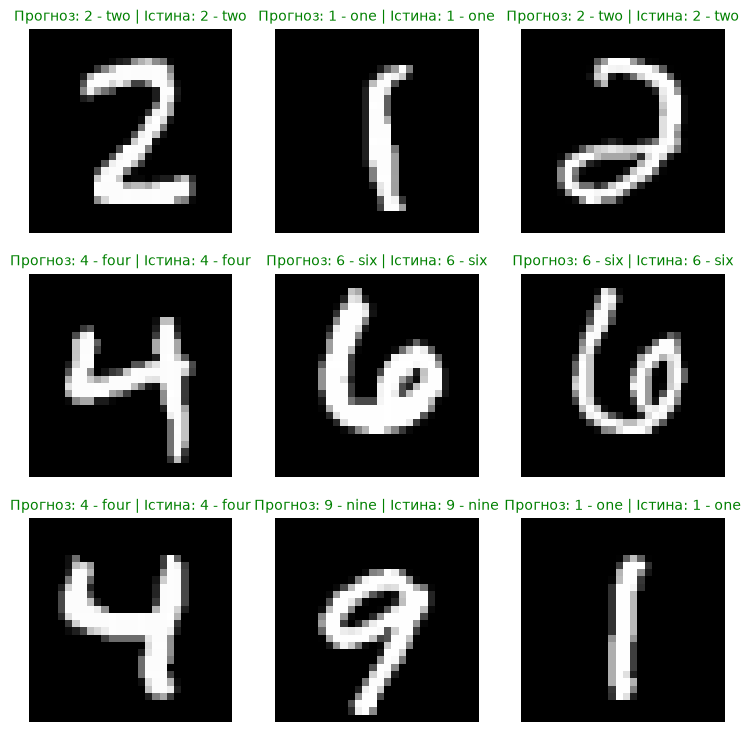

In [22]:
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)

  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = class_names[pred_classes[i]]

  truth_label = class_names[test_labels[i]]

  title_text = f"Прогноз: {pred_label} | Істина: {truth_label}"

  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g")
  else:
      plt.title(title_text, fontsize=10, c="r")
  plt.axis(False);

# Building a confusion matrix

In [23]:
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Зроблення прогнозів"):

    X, y = X.to(device), y.to(device)

    y_logit = model_2(X)

    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)

    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

Зроблення прогнозів:   0%|          | 0/313 [00:00<?, ?it/s]

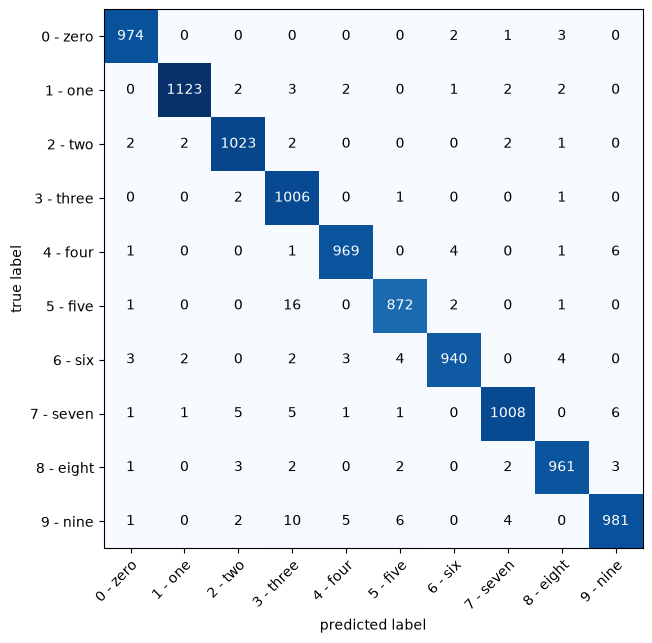

In [24]:
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# Побудова матриці плутанини
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
);

**Observation:**
- According to the confusion matrix, we can see that the values ​​on the diagonal dominate, which indicates that the model predicted the labels quite well.
- The most problematic is the recognition of 7 (often incorrectly classified as two and three), 9 (classified as 3), 5 (classified as 3).
- The best classification is 0 and 1, the worst is 5.

# Error analysis

Кількість неправильних прогнозів: 143 з 10000


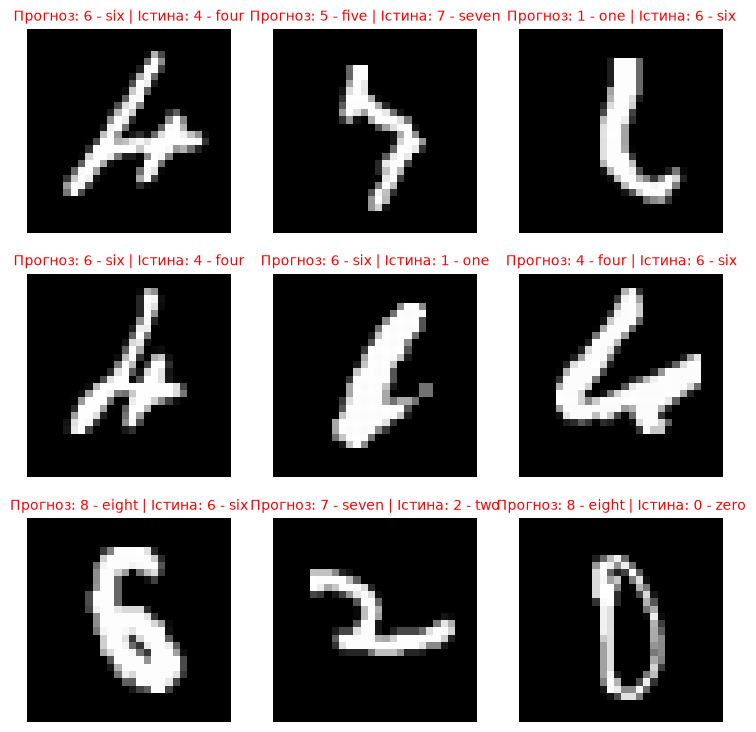

In [25]:
y_pred_tensor_cpu = y_pred_tensor
y_true_tensor = test_data.targets

wrong_idx = (y_pred_tensor_cpu != y_true_tensor).nonzero().squeeze()
print(f"Кількість неправильних прогнозів: {len(wrong_idx)} з {len(y_true_tensor)}")

torch.manual_seed(42)
wrong_samples_idx = wrong_idx[torch.randperm(len(wrong_idx))[:9]]

plt.figure(figsize=(9, 9))
nrows, ncols = 3, 3
for i, idx in enumerate(wrong_samples_idx):
    idx = idx.item()
    image, true_label = test_data[idx]

    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    pred_label_text = class_names[y_pred_tensor_cpu[idx]]
    truth_label_text = class_names[true_label]

    plt.title(f"Прогноз: {pred_label_text} | Істина: {truth_label_text}",
              fontsize=10, c="r")
    plt.axis(False)

**Observation:**
- According to the error analysis, some of the incorrectly recognized objects are quite similar to those predicted in the case of not quite clear handwriting (for example, 6 and 1, 1 and 6, 5 and 7).
- However, another part of the errors reflects obvious modeling errors, where the digit is quite clear (8 and 6, 2 and 7, 8 and 0).
- In general, given the rather good accuracy of the model, the result is acceptable for this architecture.